# Comprehensive analysis of the job market for data scientists in Europe and the US

In [27]:
import ast
import pandas as pd
import numpy as np
from datasets import load_dataset

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter
from adjustText import adjust_text

from pathlib import Path
Path('./figures').mkdir(exist_ok=True)

## Load the dataset provided by Luke Barousse

In [28]:
# Load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [29]:
# Make a dictionary of technologies (types of skills):
df_technology = df['job_type_skills'].copy()

# Remove duplicates
df_technology = df_technology.drop_duplicates()

# Remove NaN values
df_technology = df_technology.dropna()

# Combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# Remove duplicates while preserving order
for key, value in technology_dict.items():
    technology_dict[key] = list(dict.fromkeys(value))

df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')

## 1) Compare the US and European job markets

In [30]:
df_ds = df[df['job_title_short'] == 'Data Scientist'].copy()

In [31]:
european_countries = [
    'United Kingdom',
    'Ireland',
    'France',
    'Germany',
    'Portugal',
    'Spain',
    'Netherlands',
    'Italy',
    'Greece',
    'Belgium',
    'Switzerland',
    'Norway',
    'Denmark',
    'Sweden',
    'Finland',
    'Austria',
    'Poland',
    'Czechia',
    'Romania',
    'Hungary',
    'Slovakia',
    'Slovenia',
    'Croatia',
    'Bulgaria',
    'Estonia',
    'Latvia',
    'Lithuania',
    'Luxembourg',
    'Iceland',
    'Serbia',
    'Ukraine'
]

df_Europe = df[df['job_country'].isin(european_countries)].copy()
df_US = df[df['job_country'] == 'United States'].copy()

### 1.1) Compare job posting characteristics

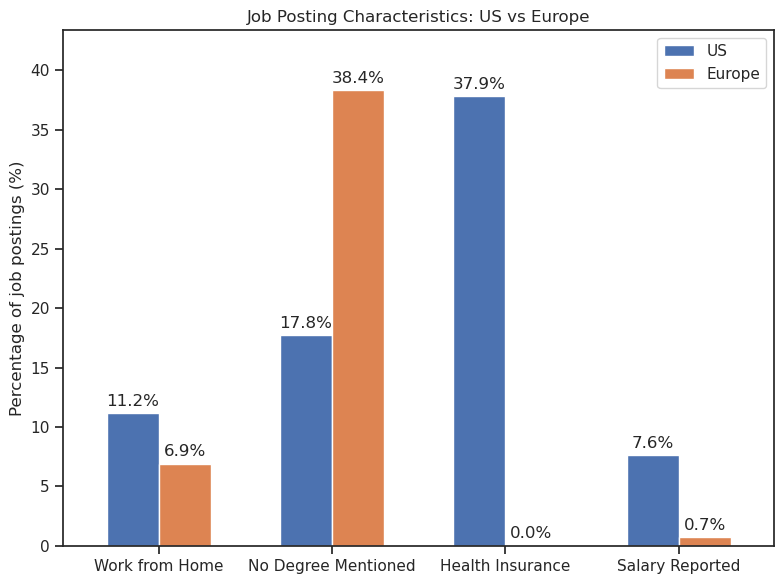

In [32]:
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'No Degree Mentioned',
    'job_health_insurance': 'Health Insurance',
    'salary_year_avg': 'Salary Reported'
}

# Calculate percentage of True for each variable. 
# For the % of postings with salary specified: .notna() is True when a salary is not NA
# and False otherwise, so the mean gives the fraction of postings with a reported salary.
comparison = pd.DataFrame({
    'US': [
        df_US['job_work_from_home'].mean() * 100,
        df_US['job_no_degree_mention'].mean() * 100,
        df_US['job_health_insurance'].mean() * 100,
        df_US['salary_year_avg'].notna().mean() * 100
    ],
    'Europe': [
        df_Europe['job_work_from_home'].mean() * 100,
        df_Europe['job_no_degree_mention'].mean() * 100,
        df_Europe['job_health_insurance'].mean() * 100,
        df_Europe['salary_year_avg'].notna().mean() * 100
    ]
}, index=dict_column.values())

# Plot
ax = comparison.plot(
    kind='bar',
    figsize=(8, 6),
    width=0.6
)

ax.set_ylabel('Percentage of job postings (%)')
ax.set_xlabel('')
ax.set_title('Job Posting Characteristics: US vs Europe')
ax.set_ylim(0, comparison.max().max() + 5)

# Put percentage values above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.savefig('./figures/01_job_posting_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.2) Analyse the required skills in each region

Percentages represent the fraction of job postings mentioning a skill. A posting mentioning several skills contributes once to each corresponding skill.

In [33]:
# ----------------------------------------------
# Get skill statistics for the US market
# ----------------------------------------------

df_US_skills = df_US.explode('job_skills')

US_skill_stats = (
    df_US_skills
    .groupby('job_skills')
    .size()
    .reset_index(name='skill_count')
)

US_skill_stats['skill_percent'] =  US_skill_stats['skill_count'] / len(df_US) * 100


# ----------------------------------------------
# Get skill statistics for the European market
# ----------------------------------------------

df_Europe_skills = df_Europe.explode('job_skills')

Europe_skill_stats = (
    df_Europe_skills
    .groupby('job_skills')
    .size()
    .reset_index(name='skill_count')
)

Europe_skill_stats['skill_percent'] = Europe_skill_stats['skill_count'] / len(df_Europe) * 100


# ----------------------------------------------------------------------------
# Get the US top 11 skills and add European percentages for those same skills
# ----------------------------------------------------------------------------

top_US = US_skill_stats.nlargest(11, 'skill_percent').copy()

top_US = top_US.merge(
    Europe_skill_stats[['job_skills', 'skill_percent']],
    on='job_skills',
    how='left',
    suffixes=('_US', '_Europe')
)

# Skills absent from Europe
top_US['skill_percent_Europe'] = top_US['skill_percent_Europe'].fillna(0)

# Order according to US ranking
top_US = top_US.sort_values('skill_percent_US')

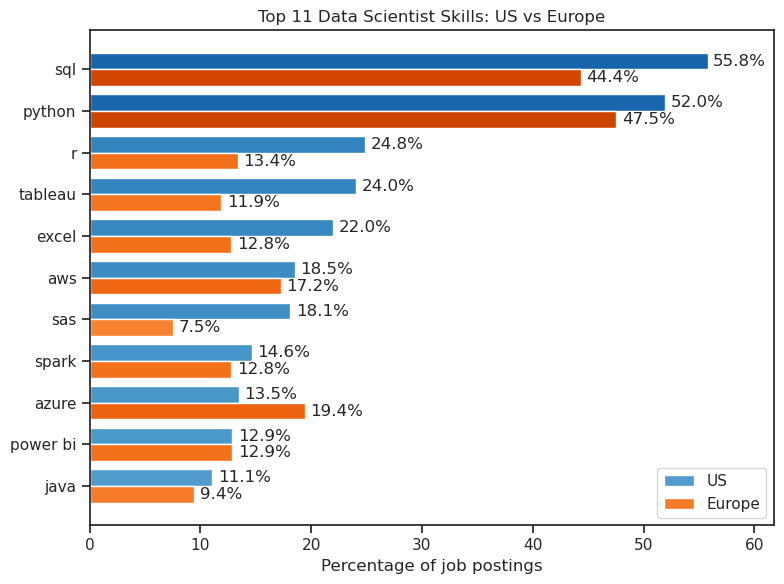

In [34]:
# Make a comparison plot

fig, ax = plt.subplots(figsize=(8, 6))

y = range(len(top_US))
height = 0.4

# ----------------------------------------------
# Color maps
# ----------------------------------------------

# Create colormaps
us_cmap = sns.color_palette('Blues', as_cmap=True)
europe_cmap = sns.color_palette('Oranges', as_cmap=True)

# Skip the darkest part of the colormaps
us_cmap = mcolors.LinearSegmentedColormap.from_list(
    'us_cmap',
    us_cmap(np.linspace(0.0, 0.8, 256))
)

europe_cmap = mcolors.LinearSegmentedColormap.from_list(
    'europe_cmap',
    europe_cmap(np.linspace(0.0, 0.8, 256))
)

# Common (non-linear) normalization
norm = mcolors.PowerNorm(
    gamma=0.2,
    vmin=0,
    vmax=max(
        top_US['skill_percent_US'].max(),
        top_US['skill_percent_Europe'].max()
    )
)

us_colors = us_cmap(norm(top_US['skill_percent_US']))
europe_colors = europe_cmap(norm(top_US['skill_percent_Europe']))


# ----------------------------------------------
# Bars
# ----------------------------------------------

ax.barh(
    [i + height/2 for i in y],
    top_US['skill_percent_US'],
    height=height,
    label='US',
    color=us_colors
)

ax.barh(
    [i - height/2 for i in y],
    top_US['skill_percent_Europe'],
    height=height,
    label='Europe',
    color=europe_colors
)


# ----------------------------------------------
# Formatting
# ----------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(top_US['job_skills'])

ax.set_xlabel('Percentage of job postings')
ax.set_ylabel('')
ax.set_title('Top 11 Data Scientist Skills: US vs Europe')


# ----------------------------------------------
# Value labels
# ----------------------------------------------

for i, (us, europe) in enumerate( zip(top_US['skill_percent_US'], top_US['skill_percent_Europe']) ):
    ax.text(
        us + 0.5,
        i + height/2,
        f'{us:.1f}%',
        va='center'
    )

    ax.text(
        europe + 0.5,
        i - height/2,
        f'{europe:.1f}%',
        va='center'
    )


ax.legend()
ax.set_xlim(0, top_US['skill_percent_US'].max().max() + 6)

plt.tight_layout()
plt.savefig('./figures/02_top_skills_us_vs_europe.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.3) Compare salary distributions

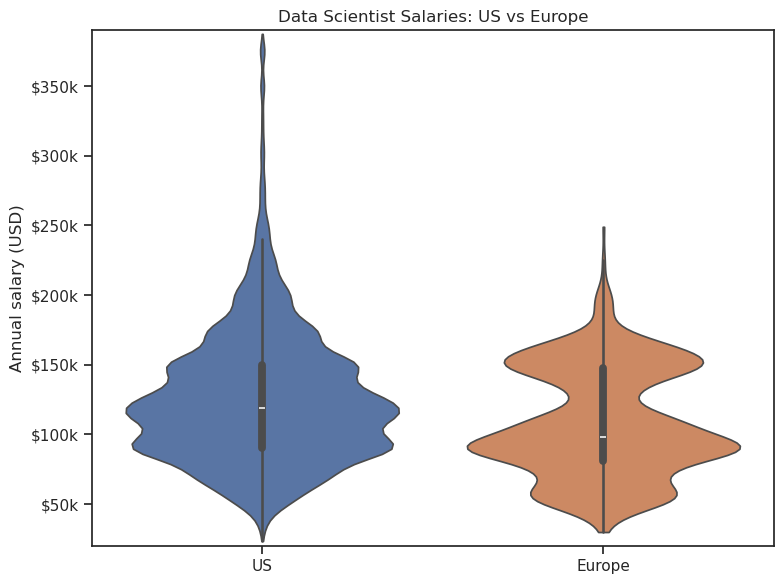

In [35]:
# Remove extreme US salary values above $400k for visualization.
salary_US = df_US[df_US['salary_year_avg'] < 400_000].copy()
salary_US['region'] = 'US'

salary_Europe = df_Europe[['salary_year_avg']].copy()
salary_Europe['region'] = 'Europe'

salary_comparison = pd.concat(
    [salary_US, salary_Europe],
    ignore_index=True
)

# Remove missing salaries
salary_comparison = salary_comparison.dropna(subset=['salary_year_avg'])

plt.figure(figsize=(8, 6))

sns.violinplot(
    data=salary_comparison,
    x='region',
    y='salary_year_avg',
    hue='region',
    palette={'US': 'C0', 'Europe': 'C1'},
    inner='box',
    cut=0
)

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}k'))
ax.set_ylim(20e3, 390e3)

plt.xlabel('')
plt.ylabel('Annual salary (USD)')
plt.title('Data Scientist Salaries: US vs Europe')

plt.tight_layout()
plt.savefig('./figures/03_salary_us_vs_europe.png', dpi=300, bbox_inches='tight')
plt.show()

## 2) Analyse the European job market in more detail

### 2.1) Visualize number of job postings per country

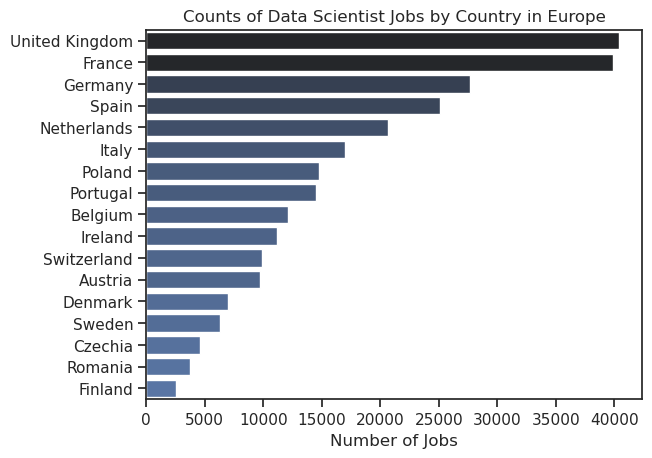

In [36]:
df_plot = df_Europe['job_country'].value_counts().to_frame(name='count').head(17) 

sns.set_theme(style='ticks')

sns.barplot(
    data=df_plot,
    x='count',
    y='job_country',
    hue='count',
    palette='dark:b_r',
    legend=False
)

plt.title('Counts of Data Scientist Jobs by Country in Europe')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.savefig('./figures/04_counts_by_european_country.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.2) Visualize median salaries per country

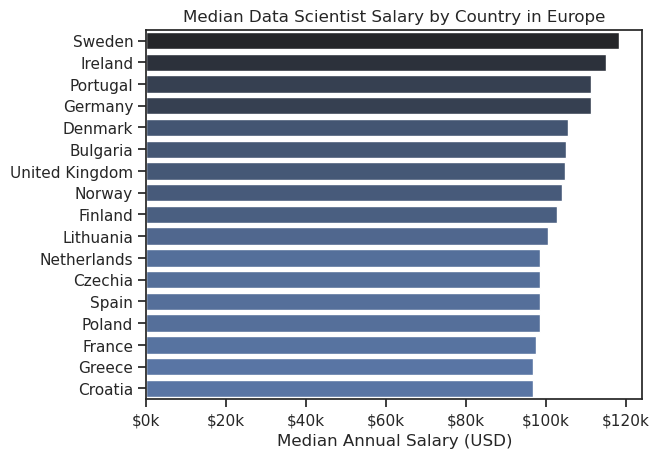

In [44]:
# Remove countries without salary information for the median salary plot
df_Europe_salary = df_Europe[df_Europe['salary_year_avg'].notna()].copy()

df_plot = (
    df_Europe_salary.groupby('job_country')['salary_year_avg']
    .median()
    .sort_values(ascending=False)
    .head(17)
    .to_frame(name='median_salary')
)

sns.set_theme(style='ticks')

sns.barplot(
    data=df_plot,
    x='median_salary',
    y='job_country',
    hue='median_salary',
    palette='dark:b_r',
    legend=False
)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.title('Median Data Scientist Salary by Country in Europe')
plt.xlabel('Median Annual Salary (USD)')
plt.ylabel('')
plt.savefig('./figures/05_salary_by_european_country.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.3) Analyse the most requested skills

Percentages represent the fraction of job postings mentioning a skill. A posting mentioning several skills contributes once to each corresponding skill.

In [45]:
# ----------------------------------------------
# Explode European job skills
# ----------------------------------------------

df_Europe_skills = df_Europe.explode('job_skills').copy()

# ----------------------------------------------
# Calculate skill statistics
# ----------------------------------------------

df_Europe_skills_stats = (
    df_Europe_skills
    .groupby('job_skills')
    .agg(
        skill_count=('job_skills', 'size'),
        salary_count=('salary_year_avg', 'count'),
        median_salary=('salary_year_avg', 'median')
    )
    .reset_index()
)

# Percentage of all European Data Scientist postings
df_Europe_skills_stats['skill_percent'] = df_Europe_skills_stats['skill_count'] / len(df_Europe) * 100

# ----------------------------------------------
# Map skills to technology categories
# ----------------------------------------------

skill_to_technology = {}

for technology, skills in technology_dict.items():
    for skill in skills:
        skill_to_technology[skill] = technology

df_Europe_skills_stats['technology'] = (
    df_Europe_skills_stats['job_skills']
    .map(skill_to_technology)
)

# -------------------------------------------------------------------
# Rename skill column for plotting, and consider only common skills
# -------------------------------------------------------------------

df_plot = df_Europe_skills_stats.rename(columns={'job_skills': 'skills'})

df_plot = df_plot[
    (df_plot['skill_count'] >= 120) &
    (df_plot['skill_percent'] >= 2) &
    (df_plot['salary_count'] >= 120)
].copy()

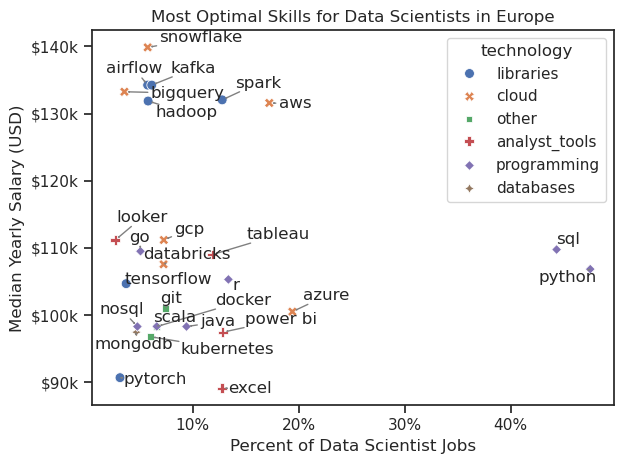

In [46]:
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    style='technology',
    s=50
)

sns.set_theme(style='ticks')

# Add text labels
texts = []
for i, txt in enumerate(df_plot['skills']):
    texts.append(plt.text(df_plot['skill_percent'].iloc[i], 
                          df_plot['median_salary'].iloc[i], 
                          txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percent of Data Scientist Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Scientists in Europe')
plt.tight_layout()
plt.savefig('./figures/06_skills_salary_europe.png', dpi=300, bbox_inches='tight')
plt.show()